# Explorative Analyse:

In [1]:
import pandas as pd
import matplotlib
%matplotlib inline

In [2]:
# - Szenario1: "an einem wochentag in 13-15 uhr erwarte ich soviele menschen in der gegend"

In [3]:
!pwd

/Users/maryammirza/PycharmProjects/pedestrian_forecast_datascience/src


In [4]:
df3310 = pd.read_csv('../data/bzm_telraam_9000003310.csv.gz.csv')
df4118 = pd.read_csv('../data/bzm_telraam_9000004118.csv.gz.csv')
df4602 = pd.read_csv('../data/bzm_telraam_9000004602.csv.gz.csv')
df4685 = pd.read_csv('../data/bzm_telraam_9000004685.csv.gz.csv')
df5444 = pd.read_csv('../data/bzm_telraam_9000005444.csv.gz.csv')
df5832 = pd.read_csv('../data/bzm_telraam_9000005832.csv.gz.csv')

dftotal= pd.concat([df3310, df4118, df4602, df4685, df5444, df5832], ignore_index=True)

In [5]:
dftotal.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,heavy_total,v85,car_speed0,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70
0,9000003310,2022-03-18 07:00,0.752500,3,1,4,19,15,33,73,...,0,24.5,8.77,47.37,36.84,6.14,0.88,0.0,0.00,0.00
1,9000003310,2022-03-18 08:00,0.797222,6,3,9,25,18,43,99,...,0,20.0,12.90,65.16,18.71,2.58,0.00,0.0,0.00,0.65
2,9000003310,2022-03-18 09:00,0.795833,0,1,1,23,13,35,83,...,0,21.0,16.18,54.41,26.47,1.47,0.74,0.0,0.74,0.00
3,9000003310,2022-03-18 10:00,0.805556,1,4,5,15,14,29,81,...,0,21.0,11.29,59.68,25.81,3.23,0.00,0.0,0.00,0.00
4,9000003310,2022-03-18 11:00,0.596667,3,0,3,30,18,49,77,...,0,22.5,18.18,45.45,32.47,1.30,1.30,1.3,0.00,0.00


In [6]:
 dftotal['pedtotal_corrected'] = (dftotal['ped_total'] * (1 - dftotal['uptime'])) + dftotal['ped_total']

In [7]:
 dftotal['cartotal_corrected'] = (dftotal['car_total'] * (1 - dftotal['uptime'])) + dftotal['car_total']

In [8]:
 dftotal['biketotal_corrected'] = (dftotal['bike_total'] * (1 - dftotal['uptime'])) + dftotal['bike_total']

In [9]:
#Wir haben einen hohen Wert rausgeworfen. Vermutlich die Demo von links..
dftotal=dftotal.drop(dftotal[dftotal['ped_total'] == 1800].index)

In [10]:
#Weitere hohe Werte vorläufig rausgenommen, aber dann wieder drin behalten, weil der Abstand gering ist.
#dftotal=dftotal.drop(dftotal[dftotal['ped_total'] == 589].index)

In [11]:
#dftotal=dftotal.drop(dftotal[dftotal['ped_total'] == 588].index)

In [12]:
#dftotal=dftotal.drop(dftotal[dftotal['ped_total'] == 520].index)

In [13]:
dftotal.describe()

,segment_id,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,car_rgt,...,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70,pedtotal_corrected,cartotal_corrected,biketotal_corrected
count,8.578100e+04,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,...,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,85781.000000,85781.00000,85781.000000,85781.000000,85781.000000
mean,9.000005e+09,0.734988,7.718481,11.107250,18.829344,26.147177,25.147224,51.290717,91.939276,108.946258,...,25.952844,32.648775,13.127147,4.538603,1.806603,0.922840,1.97121,21.569577,237.193277,66.441946
std,8.235244e+02,0.210101,13.604796,25.193481,37.169974,24.608262,26.122545,47.221376,124.246276,136.878697,...,16.973561,17.222434,12.465645,7.219215,4.362411,3.129516,5.79522,38.886429,267.325229,64.474154
min,9.000003e+09,0.000278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,9.000004e+09,0.670000,0.000000,0.000000,1.000000,8.000000,5.000000,15.000000,18.000000,19.000000,...,12.500000,23.080000,4.000000,0.000000,0.000000,0.000000,0.00000,1.235000,52.925819,18.137779
50%,9.000005e+09,0.768333,3.000000,3.000000,6.000000,20.000000,17.000000,39.000000,46.000000,51.000000,...,26.670000,34.290000,9.460000,1.700000,0.000000,0.000000,0.00000,7.275000,135.654120,48.244440
75%,9.000005e+09,0.795833,9.000000,10.000000,18.000000,38.000000,38.000000,75.000000,97.000000,143.000000,...,38.360000,43.940000,20.000000,6.250000,1.820000,0.560000,1.23000,23.146662,317.986000,97.800000
max,9.000006e+09,1.068890,424.000000,488.000000,589.000000,423.000000,720.000000,720.000000,1200.000000,1200.000000,...,100.000000,133.330000,100.000000,100.000000,100.000000,100.000000,100.00000,690.389080,4798.000800,1438.999920


In [14]:
#Datum umwandeln
dftotal["date_local"] = pd.to_datetime(dftotal["date_local"])

In [15]:
dftotal = dftotal.drop(dftotal[dftotal["uptime"]<= 0.5].index)

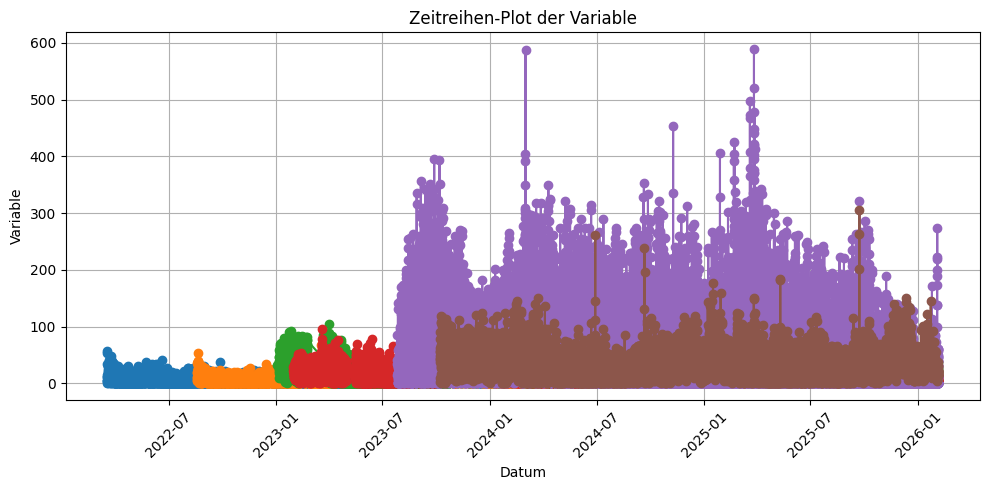

In [16]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10, 5))
for Kategorie, gruppe in dftotal.groupby('segment_id'):
    plt.plot(gruppe['date_local'], gruppe['pedtotal_corrected'], marker='o', label=Kategorie)


plt.title('Zeitreihen-Plot der Variable')
plt.xlabel('Datum')
plt.ylabel('Variable')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

In [17]:
categories = dftotal['segment_id'].unique()
num_categories = len(categories)

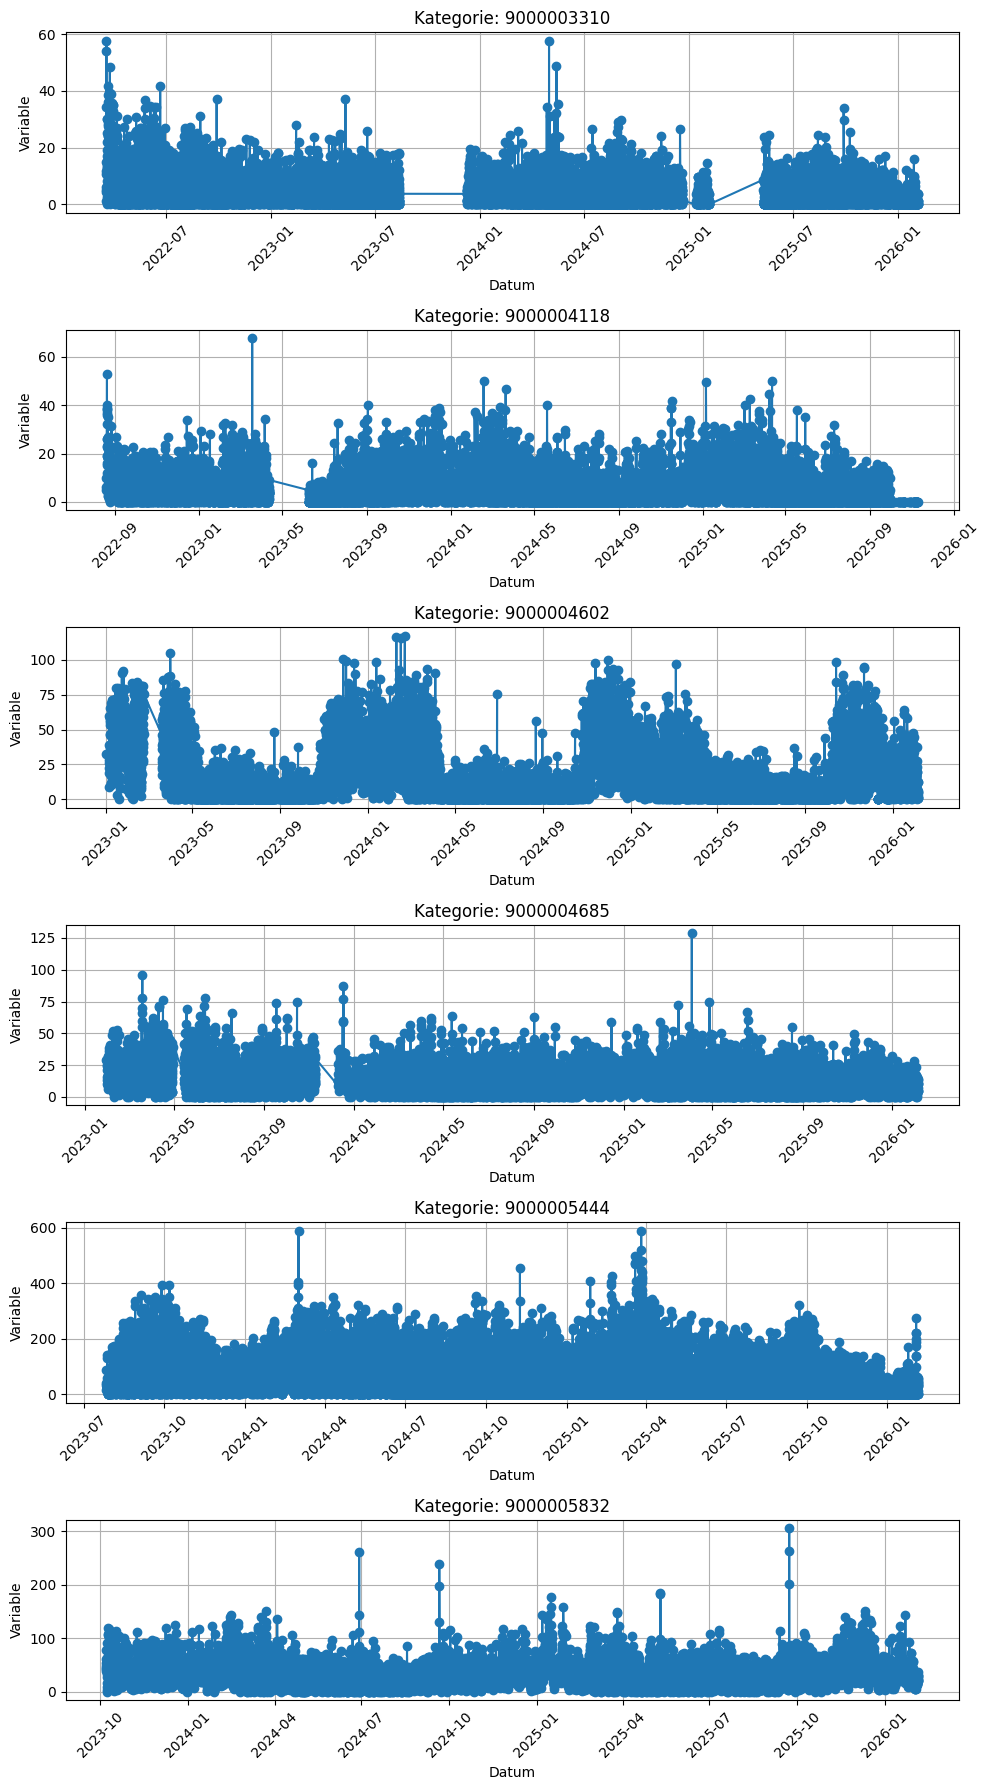

In [18]:
# Erstellen der Subplots
plt.figure(figsize=(10, num_categories * 3))  # Die Größe des Gesamtplots anpassen

# Iteriere über die Kategorien und erstelle für jede einen eigenen Plot
for i, (category, group) in enumerate(dftotal.groupby('segment_id')):
    plt.subplot(num_categories, 1, i + 1)  # Platzierung des Subplots
    plt.plot(group['date_local'], group['pedtotal_corrected'], marker='o', label=f'segment_id {category}')

    plt.title(f'Kategorie: {category}')
    plt.xlabel('Datum')
    plt.ylabel('Variable')
    plt.grid(True)
    plt.xticks(rotation=45)

plt.tight_layout()  # Für besseren Abstand zwischen den Subplots
plt.show()

In [19]:
dftotal.shape

(76615, 27)

In [20]:
dftotal.dtypes

segment_id                      int64
date_local             datetime64[ns]
uptime                        float64
ped_lft                         int64
ped_rgt                         int64
ped_total                       int64
bike_lft                        int64
bike_rgt                        int64
bike_total                      int64
car_lft                         int64
car_rgt                         int64
car_total                       int64
heavy_lft                       int64
heavy_rgt                       int64
heavy_total                     int64
v85                           float64
car_speed0                    float64
car_speed10                   float64
car_speed20                   float64
car_speed30                   float64
car_speed40                   float64
car_speed50                   float64
car_speed60                   float64
car_speed70                   float64
pedtotal_corrected            float64
cartotal_corrected            float64
biketotal_co

In [21]:
dftotal.dtypes

segment_id                      int64
date_local             datetime64[ns]
uptime                        float64
ped_lft                         int64
ped_rgt                         int64
ped_total                       int64
bike_lft                        int64
bike_rgt                        int64
bike_total                      int64
car_lft                         int64
car_rgt                         int64
car_total                       int64
heavy_lft                       int64
heavy_rgt                       int64
heavy_total                     int64
v85                           float64
car_speed0                    float64
car_speed10                   float64
car_speed20                   float64
car_speed30                   float64
car_speed40                   float64
car_speed50                   float64
car_speed60                   float64
car_speed70                   float64
pedtotal_corrected            float64
cartotal_corrected            float64
biketotal_co

In [22]:
dftotal.describe()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,car_speed10,car_speed20,car_speed30,car_speed40,car_speed50,car_speed60,car_speed70,pedtotal_corrected,cartotal_corrected,biketotal_corrected
count,7.661500e+04,76615,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,...,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000,76615.000000
mean,9.000005e+09,2024-07-31 08:03:18.666057472,0.791101,8.024108,11.801801,19.832096,26.359199,25.378464,51.733486,96.063042,...,25.878875,32.405527,13.137964,4.533578,1.795967,0.913883,1.900454,22.005638,237.814613,64.603307
min,9.000003e+09,2022-03-18 07:00:00,0.500278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.000004e+09,2023-11-28 12:00:00,0.720278,0.000000,0.000000,1.000000,9.000000,5.000000,16.000000,20.000000,...,13.120000,23.530000,4.310000,0.000000,0.000000,0.000000,0.000000,1.293472,54.242232,19.032775
50%,9.000005e+09,2024-08-19 18:00:00,0.775000,3.000000,3.000000,6.000000,21.000000,18.000000,40.000000,48.000000,...,26.670000,34.290000,9.680000,1.850000,0.000000,0.000000,0.000000,7.361664,136.155580,48.249436
75%,9.000005e+09,2025-05-24 18:00:00,0.800556,9.000000,10.000000,19.000000,38.000000,38.000000,76.000000,100.000000,...,38.100000,43.480000,20.140000,6.450000,1.890000,0.610000,1.270000,23.342780,321.301213,95.726952
max,9.000006e+09,2026-02-04 16:00:00,1.068890,199.000000,488.000000,589.000000,321.000000,214.000000,371.000000,650.000000,...,100.000000,133.330000,100.000000,100.000000,100.000000,100.000000,100.000000,589.327484,1553.711992,487.200000
std,8.260776e+02,NaN,0.131041,13.801734,26.195822,38.536173,23.771473,25.476136,46.226809,127.673301,...,16.231181,16.174563,11.725414,6.574852,3.953906,2.847665,5.301337,39.212006,263.069735,59.320222


In [23]:
dftotal.isna().sum()

segment_id                0
date_local                0
uptime                    0
ped_lft                   0
ped_rgt                   0
ped_total                 0
bike_lft                  0
bike_rgt                  0
bike_total                0
car_lft                   0
car_rgt                   0
car_total                 0
heavy_lft                 0
heavy_rgt                 0
heavy_total               0
v85                    6340
car_speed0                0
car_speed10               0
car_speed20               0
car_speed30               0
car_speed40               0
car_speed50               0
car_speed60               0
car_speed70               0
pedtotal_corrected        0
cartotal_corrected        0
biketotal_corrected       0
dtype: int64

In [24]:
#Prozent der fehlenden Werte in jeder Spalte:
dftotal.isna().mean()
#1 steht für 100 Prozent, da wo 1.0 steht = fehlen alle Werte
# und wo 0.0 steht = keine Werte fehlen.

segment_id             0.000000
date_local             0.000000
uptime                 0.000000
ped_lft                0.000000
ped_rgt                0.000000
ped_total              0.000000
bike_lft               0.000000
bike_rgt               0.000000
bike_total             0.000000
car_lft                0.000000
car_rgt                0.000000
car_total              0.000000
heavy_lft              0.000000
heavy_rgt              0.000000
heavy_total            0.000000
v85                    0.082751
car_speed0             0.000000
car_speed10            0.000000
car_speed20            0.000000
car_speed30            0.000000
car_speed40            0.000000
car_speed50            0.000000
car_speed60            0.000000
car_speed70            0.000000
pedtotal_corrected     0.000000
cartotal_corrected     0.000000
biketotal_corrected    0.000000
dtype: float64

# Preprocessing:

In [25]:
df_wetter = pd.read_csv('../data/produkt_klima_tag_19480101_20241231_00433.txt',sep=';')

In [26]:
df_wetter.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,433,19480101,-999,-999.0,-999.0,5,5.7,8,-999.0,4,5.0,4.9,1010.7,-1.8,89.0,0.8,-5.0,-4.7,eor
1,433,19480102,-999,-999.0,-999.0,5,3.3,1,-999.0,8,8.0,7.9,999.7,4.4,95.0,6.8,-2.7,-2.5,eor
2,433,19480103,-999,-999.0,-999.0,5,4.0,1,-999.0,0,5.3,9.8,1001.7,8.5,86.0,10.6,5.2,4.6,eor
3,433,19480104,-999,-999.0,-999.0,5,0.2,1,-999.0,0,8.0,10.2,999.8,10.2,83.0,11.5,6.6,4.7,eor
4,433,19480105,-999,-999.0,-999.0,5,2.0,1,-999.0,0,7.7,9.8,987.8,10.5,78.0,12.0,8.0,5.9,eor


In [27]:
df_wetter.describe()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK
count,28125.0,2.812500e+04,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000
mean,433.0,1.986067e+07,-332.326684,-333.769447,-338.745451,7.647111,1.148025,2.658204,-323.634244,-179.626702,-176.004928,7.754002,1007.436762,9.948064,71.826633,13.732423,6.071957,3.560498
std,0.0,2.222714e+05,476.976060,478.711936,475.611067,2.321363,21.027417,14.918028,470.907543,384.302729,386.276227,41.812055,64.000857,7.877128,46.303571,8.998230,7.005936,6.966770
min,433.0,1.948010e+07,-999.000000,-999.000000,-999.000000,5.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-999.000000,-18.500000,-999.000000,-17.000000,-22.500000,-28.200000
25%,433.0,1.967040e+07,-999.000000,-999.000000,-999.000000,5.000000,0.000000,0.000000,-999.000000,0.000000,1.300000,6.400000,1003.900000,3.900000,64.000000,6.600000,0.900000,-1.000000
50%,433.0,1.986070e+07,10.000000,7.800000,2.600000,9.000000,0.000000,1.000000,0.400000,0.000000,5.000000,8.900000,1009.700000,10.000000,75.000000,13.800000,6.200000,3.700000
75%,433.0,2.005100e+07,10.000000,11.200000,4.100000,10.000000,1.400000,6.000000,5.800000,0.000000,7.000000,12.300000,1015.300000,16.200000,84.000000,20.800000,11.800000,9.000000
max,433.0,2.024123e+07,10.000000,36.000000,14.500000,10.000000,119.500000,8.000000,16.300000,55.000000,8.000000,23.500000,1041.600000,30.500000,100.000000,38.500000,23.900000,20.000000


In [28]:
#Mess_datum in ein Datum umwandeln
df_wetter["MESS_DATUM"] = pd.to_datetime(df_wetter["MESS_DATUM"], format="%Y%m%d") #hiermit wird das Datum umgewandelt, damit es in Zukunft einfacher zu handhaben ist. Das Format ist JahrMonatTag, deswegen %Y%md%Y%m%d

In [29]:
df_wetter.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,NM,VPM,PM,TMK,UPM,TXK,TNK,TGK,eor
0,433,1948-01-01,-999,-999.0,-999.0,5,5.7,8,-999.0,4,5.0,4.9,1010.7,-1.8,89.0,0.8,-5.0,-4.7,eor
1,433,1948-01-02,-999,-999.0,-999.0,5,3.3,1,-999.0,8,8.0,7.9,999.7,4.4,95.0,6.8,-2.7,-2.5,eor
2,433,1948-01-03,-999,-999.0,-999.0,5,4.0,1,-999.0,0,5.3,9.8,1001.7,8.5,86.0,10.6,5.2,4.6,eor
3,433,1948-01-04,-999,-999.0,-999.0,5,0.2,1,-999.0,0,8.0,10.2,999.8,10.2,83.0,11.5,6.6,4.7,eor
4,433,1948-01-05,-999,-999.0,-999.0,5,2.0,1,-999.0,0,7.7,9.8,987.8,10.5,78.0,12.0,8.0,5.9,eor


In [30]:
#Zusätzliche Spalten für Tag, Monat, Jahr
df_wetter["day"] = df_wetter["MESS_DATUM"].dt.day
df_wetter["month"] = df_wetter["MESS_DATUM"].dt.month
df_wetter["year"] = df_wetter["MESS_DATUM"].dt.year


In [31]:
df_wetter.isna().sum()

STATIONS_ID    0
MESS_DATUM     0
QN_3           0
  FX           0
  FM           0
QN_4           0
 RSK           0
RSKF           0
 SDK           0
SHK_TAG        0
  NM           0
 VPM           0
  PM           0
 TMK           0
 UPM           0
 TXK           0
 TNK           0
 TGK           0
eor            0
day            0
month          0
year           0
dtype: int64

In [32]:
df_wetter.head()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,...,PM,TMK,UPM,TXK,TNK,TGK,eor,day,month,year
0,433,1948-01-01,-999,-999.0,-999.0,5,5.7,8,-999.0,4,...,1010.7,-1.8,89.0,0.8,-5.0,-4.7,eor,1,1,1948
1,433,1948-01-02,-999,-999.0,-999.0,5,3.3,1,-999.0,8,...,999.7,4.4,95.0,6.8,-2.7,-2.5,eor,2,1,1948
2,433,1948-01-03,-999,-999.0,-999.0,5,4.0,1,-999.0,0,...,1001.7,8.5,86.0,10.6,5.2,4.6,eor,3,1,1948
3,433,1948-01-04,-999,-999.0,-999.0,5,0.2,1,-999.0,0,...,999.8,10.2,83.0,11.5,6.6,4.7,eor,4,1,1948
4,433,1948-01-05,-999,-999.0,-999.0,5,2.0,1,-999.0,0,...,987.8,10.5,78.0,12.0,8.0,5.9,eor,5,1,1948


In [33]:
dftotal["day"] = dftotal["date_local"].dt.day
dftotal["month"] = dftotal["date_local"].dt.month
dftotal["year"] = dftotal["date_local"].dt.year

In [34]:
dftotal.head()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,car_speed40,car_speed50,car_speed60,car_speed70,pedtotal_corrected,cartotal_corrected,biketotal_corrected,day,month,year
0,9000003310,2022-03-18 07:00:00,0.752500,3,1,4,19,15,33,73,...,0.88,0.0,0.00,0.00,4.990000,188.372500,41.167500,18,3,2022
1,9000003310,2022-03-18 08:00:00,0.797222,6,3,9,25,18,43,99,...,0.00,0.0,0.00,0.65,10.825002,233.338932,51.719454,18,3,2022
2,9000003310,2022-03-18 09:00:00,0.795833,0,1,1,23,13,35,83,...,0.74,0.0,0.74,0.00,1.204167,205.912557,42.145845,18,3,2022
3,9000003310,2022-03-18 10:00:00,0.805556,1,4,5,15,14,29,81,...,0.00,0.0,0.00,0.00,5.972220,183.944376,34.638876,18,3,2022
4,9000003310,2022-03-18 11:00:00,0.596667,3,0,3,30,18,49,77,...,1.30,1.3,0.00,0.00,4.209999,181.029957,68.763317,18,3,2022


In [35]:
df_wetter.describe()

,STATIONS_ID,MESS_DATUM,QN_3,FX,FM,QN_4,RSK,RSKF,SDK,SHK_TAG,...,VPM,PM,TMK,UPM,TXK,TNK,TGK,day,month,year
count,28125.0,28125,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,...,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000,28125.000000
mean,433.0,1986-07-02 00:00:00,-332.326684,-333.769447,-338.745451,7.647111,1.148025,2.658204,-323.634244,-179.626702,...,7.754002,1007.436762,9.948064,71.826633,13.732423,6.071957,3.560498,15.729991,6.522809,1986.000000
min,433.0,1948-01-01 00:00:00,-999.000000,-999.000000,-999.000000,5.000000,-999.000000,-999.000000,-999.000000,-999.000000,...,-999.000000,-999.000000,-18.500000,-999.000000,-17.000000,-22.500000,-28.200000,1.000000,1.000000,1948.000000
25%,433.0,1967-04-02 00:00:00,-999.000000,-999.000000,-999.000000,5.000000,0.000000,0.000000,-999.000000,0.000000,...,6.400000,1003.900000,3.900000,64.000000,6.600000,0.900000,-1.000000,8.000000,4.000000,1967.000000
50%,433.0,1986-07-02 00:00:00,10.000000,7.800000,2.600000,9.000000,0.000000,1.000000,0.400000,0.000000,...,8.900000,1009.700000,10.000000,75.000000,13.800000,6.200000,3.700000,16.000000,7.000000,1986.000000
75%,433.0,2005-10-01 00:00:00,10.000000,11.200000,4.100000,10.000000,1.400000,6.000000,5.800000,0.000000,...,12.300000,1015.300000,16.200000,84.000000,20.800000,11.800000,9.000000,23.000000,10.000000,2005.000000
max,433.0,2024-12-31 00:00:00,10.000000,36.000000,14.500000,10.000000,119.500000,8.000000,16.300000,55.000000,...,23.500000,1041.600000,30.500000,100.000000,38.500000,23.900000,20.000000,31.000000,12.000000,2024.000000
std,0.0,NaN,476.976060,478.711936,475.611067,2.321363,21.027417,14.918028,470.907543,384.302729,...,41.812055,64.000857,7.877128,46.303571,8.998230,7.005936,6.966770,8.800398,3.448798,22.227114


In [36]:
# Spaltennamen fixen- Leerzeichen entfernen
df_wetter.columns = df_wetter.columns.str.strip()  # Entfernt Leerzeichen am Anfang und Ende

In [37]:
# Beide DataFrames mergen (zusammenführen)
df_alles = pd.merge(
    dftotal,
    df_wetter[["RSK", "SDK", "TMK", "STATIONS_ID", "MESS_DATUM", "year", "month", "day"]],
    left_on=["year", "month", "day"],
    right_on=["year", "month", "day"],
    how="inner" #inner schmeißt alles raus was nicht in beiden DataFrames steht
)

In [38]:
df_alles.shape

(47592, 35)

In [39]:
dftotal.shape

(76615, 30)

In [40]:
df_alles.describe()

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,cartotal_corrected,biketotal_corrected,day,month,year,RSK,SDK,TMK,STATIONS_ID,MESS_DATUM
count,4.759200e+04,47592,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,...,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.000000,47592.0,47592
mean,9.000005e+09,2024-01-01 02:11:10.877458176,0.776032,8.174168,11.943037,20.123172,27.978757,26.235922,54.211989,100.742772,...,252.551495,67.916962,15.888952,6.842242,2023.472264,-9.297556,-941.524952,13.556163,433.0,2023-12-31 13:55:00.453857792
min,9.000003e+09,2022-03-18 07:00:00,0.500278,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,2022.000000,-999.000000,-999.000000,-7.700000,433.0,2022-03-18 00:00:00
25%,9.000004e+09,2023-07-05 19:00:00,0.711389,0.000000,0.000000,2.000000,10.000000,7.000000,20.000000,25.000000,...,69.757711,23.395413,8.000000,4.000000,2023.000000,0.000000,-999.000000,7.800000,433.0,2023-07-05 00:00:00
50%,9.000005e+09,2024-03-06 17:00:00,0.771111,3.000000,3.000000,6.000000,23.000000,19.000000,43.000000,56.000000,...,152.698922,52.010274,16.000000,7.000000,2024.000000,0.000000,-999.000000,14.600000,433.0,2024-03-06 00:00:00
75%,9.000005e+09,2024-07-23 08:00:00,0.794444,9.000000,10.000000,18.000000,39.000000,38.000000,77.000000,109.000000,...,339.245834,97.889160,24.000000,9.000000,2024.000000,1.300000,-999.000000,19.500000,433.0,2024-07-23 00:00:00
max,9.000006e+09,2024-12-31 23:00:00,1.068890,142.000000,488.000000,588.000000,321.000000,214.000000,371.000000,650.000000,...,1553.711992,487.200000,31.000000,12.000000,2024.000000,36.300000,15.400000,30.000000,433.0,2024-12-31 00:00:00
std,8.266588e+02,NaN,0.122491,13.959001,26.518276,39.033103,23.724055,25.075763,45.636235,125.792078,...,263.029100,58.788664,8.828534,3.068840,0.668584,104.203143,233.585131,7.188532,0.0,NaN


In [41]:
countminus= (df_alles["SDK"]==-999.000000).sum()

In [42]:
countminus2= (df_alles["RSK"]==-999.000000).sum()

In [43]:
countminus3= (df_alles["TMK"]==-999.000000).sum()

In [44]:
countminus

np.int64(44875)

In [45]:
countminus2

np.int64(521)

In [46]:
countminus3

np.int64(0)

In [47]:
df_alles.head(4000)

,segment_id,date_local,uptime,ped_lft,ped_rgt,ped_total,bike_lft,bike_rgt,bike_total,car_lft,...,cartotal_corrected,biketotal_corrected,day,month,year,RSK,SDK,TMK,STATIONS_ID,MESS_DATUM
0,9000003310,2022-03-18 07:00:00,0.752500,3,1,4,19,15,33,73,...,188.372500,41.167500,18,3,2022,0.0,9.2,8.6,433,2022-03-18
1,9000003310,2022-03-18 08:00:00,0.797222,6,3,9,25,18,43,99,...,233.338932,51.719454,18,3,2022,0.0,9.2,8.6,433,2022-03-18
2,9000003310,2022-03-18 09:00:00,0.795833,0,1,1,23,13,35,83,...,205.912557,42.145845,18,3,2022,0.0,9.2,8.6,433,2022-03-18
3,9000003310,2022-03-18 10:00:00,0.805556,1,4,5,15,14,29,81,...,183.944376,34.638876,18,3,2022,0.0,9.2,8.6,433,2022-03-18
4,9000003310,2022-03-18 11:00:00,0.596667,3,0,3,30,18,49,77,...,181.029957,68.763317,18,3,2022,0.0,9.2,8.6,433,2022-03-18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,9000003310,2023-03-01 17:00:00,0.761111,1,1,3,14,7,21,113,...,227.955576,26.016669,1,3,2023,0.0,-999.0,1.5,433,2023-03-01
3996,9000003310,2023-03-02 07:00:00,0.761389,5,4,9,7,7,13,63,...,144.917487,16.101943,2,3,2023,0.0,-999.0,0.1,433,2023-03-02
3997,9000003310,2023-03-02 08:00:00,0.798056,4,1,5,18,10,28,50,...,156.252720,33.654432,2,3,2023,0.0,-999.0,0.1,433,2023-03-02
3998,9000003310,2023-03-02 09:00:00,0.792500,4,0,4,16,6,23,67,...,184.747500,27.772500,2,3,2023,0.0,-999.0,0.1,433,2023-03-02


In [48]:
df_alles["stuendchen"]= df_alles["date_local"].dt.hour

# Modelling

## Testsplit für alle Modelle:

In [49]:
from sklearn.model_selection import train_test_split

In [50]:
# Features (X) und Ziel-Variable (y) definieren
X = df_alles[["RSK", "TMK", "stuendchen", "biketotal_corrected", "cartotal_corrected"]]  # Wetterdaten als Features
y = df_alles["pedtotal_corrected"]  # Fußgängerinnen als Ziel-Variable

In [51]:
# Train/Test Split (80% Training, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Baseline Modell 1: Mittelwert pro Stunde

In [52]:
baselinemodel1 = dftotal.groupby(dftotal["date_local"].dt.hour)["pedtotal_corrected"].mean()
baselinemodel1.reset_index().rename(columns={"date_local": "Stunde"}) #alle mittelwerte von pedtotal
#todo: Baseline Modelle evaluieren und mit lin Reg und Random Forest vergleichen

,Stunde,pedtotal_corrected
0,0,0.000000
1,1,0.000000
2,2,0.000000
3,3,0.000000
4,4,0.272900
5,5,4.416807
6,6,9.514380
7,7,19.579288
8,8,25.742468
9,9,25.350002


In [53]:
#Evaluation des BaselineModells:
# TODO: Modell auf den Trainingsdaten ausrechnen
# TODO: Vorhersage für eine Station und einen Zeitraum

In [54]:
#Wie viel Leute zwischen 13 und 15 uhr erwarte ich im gesamten Umkreis im Durchschnitt aller Station?
#von 13-14 Uhr ist der Durchnitt für pedtotal= 20.134553 + 24.612427 = 44.74698.
#Das Modell berücksichtigt keine Unterschiede zwischen den Tagen, also dass z.b. am Mo unterschiedlich viele Leute unterwegs sind als am So.

## Lineares Regressionsmodell

In [55]:
#Lineare Regression:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [56]:
df_alles.isna().sum()

segment_id                0
date_local                0
uptime                    0
ped_lft                   0
ped_rgt                   0
ped_total                 0
bike_lft                  0
bike_rgt                  0
bike_total                0
car_lft                   0
car_rgt                   0
car_total                 0
heavy_lft                 0
heavy_rgt                 0
heavy_total               0
v85                    2120
car_speed0                0
car_speed10               0
car_speed20               0
car_speed30               0
car_speed40               0
car_speed50               0
car_speed60               0
car_speed70               0
pedtotal_corrected        0
cartotal_corrected        0
biketotal_corrected       0
day                       0
month                     0
year                      0
RSK                       0
SDK                       0
TMK                       0
STATIONS_ID               0
MESS_DATUM                0
stuendchen          

In [57]:
# Daten normalisieren mit StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [58]:
# Lineares Regressionsmodell trainieren
model_linreg1 = LinearRegression()
model_linreg1.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [59]:
# Koeffizienten anzeigen / Gewichtungen
print("Modell-Koeffizienten:")
for feature, coef in zip(["RSK", "TMK", "stuendchen", "biketotal_corrected", "cartotal_corrected"], model_linreg1.coef_):
    print(f"{feature:10s}: {coef:10.4f}")
print(f"Intercept: {model_linreg1.intercept_:10.4f}")

Modell-Koeffizienten:
RSK       :    -0.1101
TMK       :    -2.6527
stuendchen:    -1.4495
biketotal_corrected:     2.1921
cartotal_corrected:    26.4312
Intercept:    22.3987


In [60]:
#wenn die Stunden sinkt die Anzahl der Fußganegerinnen
#Wenn die Niederschlagsmenge steigt, dann sinkt die Anzahl der Fußgängerinnen
#Intercept = Achsenabschnitt

In [61]:
# Vorhersagen machen
y_pred_train = model_linreg1.predict(X_train_scaled)
y_pred_test = model_linreg1.predict(X_test_scaled)


In [62]:
# Modell evaluieren
train_mae = mean_absolute_error(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_r2 = r2_score(y_train, y_pred_train)

test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
test_r2 = r2_score(y_test, y_pred_test)


print("Model Evaluation")

print(f"{'Metrik':<15} {'Training':<15} {'Test':<15}")
print(f"{'MAE':<15} {train_mae:<15.2f} {test_mae:<15.2f}")
print(f"{'RMSE':<15} {train_rmse:<15.2f} {test_rmse:<15.2f}")
print(f"{'R²':<15} {train_r2:<15.4f} {test_r2:<15.4f}")

Model Evaluation
Metrik          Training        Test           
MAE             18.04           18.32          
RMSE            29.44           29.86          
R²              0.4498          0.4321         


## Random Forest Modell

In [63]:
# Beide DataFrames mergen (zusammenführen) für Random Forest
df_alles_random_forest = pd.merge(
    dftotal,
    df_wetter[["RSK", "SDK", "TMK", "STATIONS_ID", "MESS_DATUM", "year", "month", "day"]],
    left_on=["year", "month", "day"],
    right_on=["year", "month", "day"],
    how="left"
)

In [64]:
from sklearn.ensemble import RandomForestRegressor

# Stunde extrahieren
df_alles_random_forest["stuendchen"] = df_alles_random_forest["date_local"].dt.hour

# Wochentag Feature hinzufügen (0=Montag, 6=Sonntag)
df_alles_random_forest["dayofweek"] = df_alles_random_forest["date_local"].dt.dayofweek
df_alles_random_forest["is_weekend"] = (df_alles_random_forest["dayofweek"] >= 5).astype(int)

# -999 Werte durch NaN ersetzen und mit Median füllen (Random Forest kann das besser handhaben)
df_alles_random_forest["RSK"] = df_alles_random_forest["RSK"].replace(-999, np.nan).fillna(df_alles_random_forest["RSK"].median())
df_alles_random_forest["SDK"] = df_alles_random_forest["SDK"].replace(-999, np.nan).fillna(df_alles_random_forest["SDK"].median())
df_alles_random_forest["TMK"] = df_alles_random_forest["TMK"].replace(-999, np.nan).fillna(df_alles_random_forest["TMK"].median())

In [68]:
# Features für Random Forest
features = ["segment_id","stuendchen", "dayofweek", "is_weekend", "month", "RSK", "SDK", "TMK", "biketotal_corrected", "cartotal_corrected", "year", "day"]

X_rf = df_alles_random_forest[features]
y_rf = df_alles_random_forest["pedtotal_corrected"]

# Train/Test Split
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, random_state=42
)

In [81]:
# Random Forest trainieren
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_rf, y_train_rf)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",1000
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

## Hyperparameter Tuning mit 5-Fold Cross-Validation

In [83]:
from sklearn.model_selection import GridSearchCV

# Hyperparameter-Grid definieren
param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8]
}

# Random Forest Base Model
#hier sind die Parameter drin die immer gleich sein sollen
rf_base = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# GridSearchCV mit 5-Fold Cross-Validation
# cv = 5 Folds
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error', #Metrik um die Random Forest Modell zu vergleichen
    verbose=2,
    n_jobs=-1
)

# Grid Search durchführen
grid_search.fit(X_train_rf, y_train_rf)

Starte Hyperparameter-Tuning mit 5-Fold Cross-Validation...
Fitting 5 folds for each of 80 candidates, totalling 400 fits
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   4.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   5.1s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   5.2s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.3s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.7s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   5.4s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=2; total time=   5.8s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   5.8s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_split=5; total time=   5.5s
[CV] END max_depth=5, min_samples_leaf=1, min_samples_spli

/Users/maryammirza/PycharmProjects/pedestrian_forecast_datascience/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time=  11.9s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time=  11.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time=  11.5s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time=  11.8s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=10; total time=  11.6s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_split=20; total time=  12.8s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=  17.3s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=  17.3s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=  17.4s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=  17.5s
[CV] END max_depth=None, min_samples_leaf=2, min_samples_split=2; total time=  17.4s
[CV] END max_depth=None, min_samples_leaf=1, min_samples_sp

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidat

In [86]:
print("\nBeste Hyperparameter:")
print(grid_search.best_params_)


Beste Hyperparameter:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [87]:
# Modell mit besten Parametern evaluieren
best_rf_model = grid_search.best_estimator_

y_pred_best_train = best_rf_model.predict(X_train_rf)
y_pred_best_test = best_rf_model.predict(X_test_rf)

best_train_mae = mean_absolute_error(y_train_rf, y_pred_best_train)
best_train_rmse = np.sqrt(mean_squared_error(y_train_rf, y_pred_best_train))
best_train_r2 = r2_score(y_train_rf, y_pred_best_train)

best_test_mae = mean_absolute_error(y_test_rf, y_pred_best_test)
best_test_rmse = np.sqrt(mean_squared_error(y_test_rf, y_pred_best_test))
best_test_r2 = r2_score(y_test_rf, y_pred_best_test)

print("\nRandom Forest (nach Hyperparameter-Tuning)")
print(f"{'Metrik':<15} {'Training':<15} {'Test':<15}")
print(f"{'MAE':<15} {best_train_mae:<15.2f} {best_test_mae:<15.2f}")
print(f"{'RMSE':<15} {best_train_rmse:<15.2f} {best_test_rmse:<15.2f}")
print(f"{'R²':<15} {best_train_r2:<15.4f} {best_test_r2:<15.4f}")


Random Forest (nach Hyperparameter-Tuning)
Metrik          Training        Test           
MAE             3.28            8.95           
RMSE            6.64            17.74          
R²              0.9711          0.8003         
